Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.XTIZUW_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


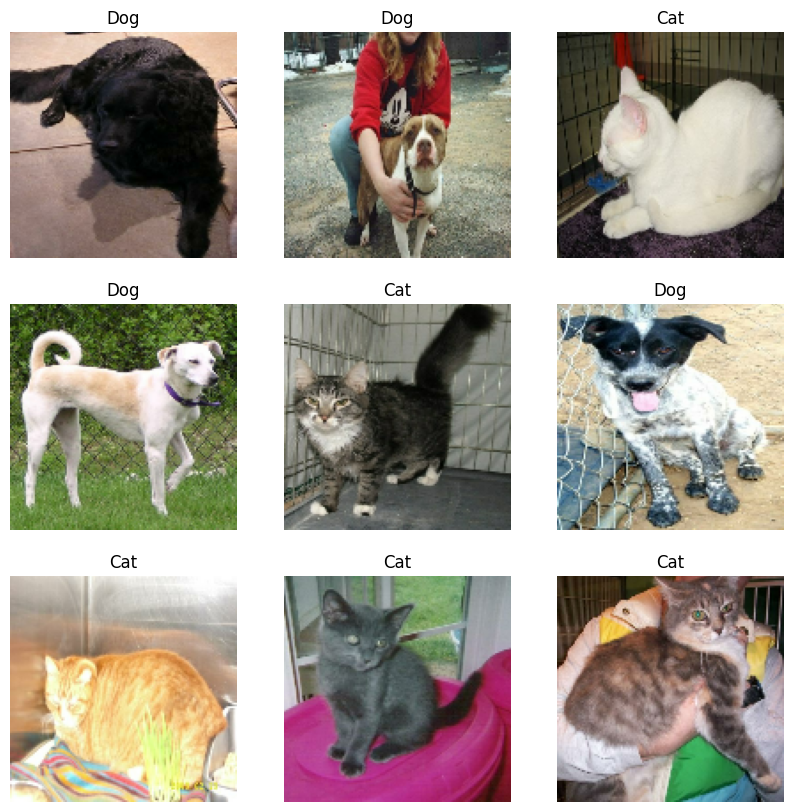

Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


582/582 ━━━━━━━━━━━━━━━━━━━━ 454s 776ms/step - accuracy: 0.6091 - loss: 0.7739 - val_accuracy: 0.7128 - val_loss: 0.5748
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 437s 750ms/step - accuracy: 0.7245 - loss: 0.5427 - val_accuracy: 0.7272 - val_loss: 0.5470
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 441s 749ms/step - accuracy: 0.7959 - loss: 0.4365 - val_accuracy: 0.7459 - val_loss: 0.5621
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 437s 751ms/step - accuracy: 0.8736 - loss: 0.2975 - val_accuracy: 0.7309 - val_loss: 0.6959
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 435s 747ms/step - accuracy: 0.9348 - loss: 0.1668 - val_accuracy: 0.7291 - val_loss: 0.7709
146/146 ━━━━━━━━━━━━━━━━━━━━ 31s 212ms/step - accuracy: 0.7206 - loss: 0.7921
Test Accuracy: 0.73


In [ ]:
# TASK 2
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

#load data
(train_ds, test_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True
)

def preprocess(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Preprocessing
train_ds = train_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)

#  Display Sample Images
class_names = ['Cat', 'Dog']
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        label = class_names[labels[i].numpy()]
        plt.title(label)
        plt.axis("off")
plt.show()

#  Build the Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

#  Compile
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train
model.fit(train_ds, epochs=5, validation_data=test_ds)

# Evaluate
loss, acc = model.evaluate(test_ds)
print(f"Test Accuracy: {acc:.2f}")
